[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eirasf/GCED-AA2/blob/main/es/lab4/lab4.ipynb)
# Práctica 4: Redes neuronales con Regularización
## El sobreajuste (overfitting)
El problema del sobreajuste (*overfitting*) consiste en que la solución aprendida se ajusta muy bien a los datos de entrenamiento, pero no generaliza adecuadamente ante la aparición de nuevos datos.

Para observar el sobreajuste en un problema, revisitaremos el problema de clasificación con datos del Titanic que hemos utilizado en los anteriores laboratorios. En primer lugar, carga los datos tal como se hacía en los anteriores notebooks. Asegúrate de tener una partición de entrenamiento con el 50\% de los datos y una de test con el 25\% y una de validación con el 25\% restante. Utiliza la función [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) de `sklearn` sobre el `ndarray` de datos en dos veces sucesivas para conseguir las particiones. Después pasa los conjuntos resultantes a `torch` y envuélvelos en un `Dataloader` como se hacía en el laboratorio anterior.

**IMPORTANTE:** La separación de conjuntos debe hacerse sobre los datos sin preprocesar. Todo preprocesado se debe hacer sobre cada conjunto por separado, pero utilizando solo información del conjunto de entrenamiento. **Revisa la carga de datos de Titanic** para que la estandarización (paso 4 de la función de carga de datos) se realice después de la partición. La función devolverá los datos sin escalar y, tras hacer la separación en train/test/val, utilizaremos un único `StandardScaler` con el que haremos `fit_transform` sobre train y `transform` sobre test y val. Así evitaremos que se filtre ningún tipo de información de test/val al entrenamiento.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def load_titanic_raw():
    # 1. Cargamos el dataset Titanic desde seaborn
    df = sns.load_dataset('titanic')

    # Selección de variables relevantes y limpieza
    cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
    df = df[cols].copy()

    # Eliminamos filas con valores faltantes
    df = df.dropna(subset=['age', 'embarked', 'fare'])

    # 2. Separar etiquetas y características
    y = df['survived'].to_numpy().astype(np.float32)
    X = df.drop(columns=['survived'])

    # 3. One-hot encoding para variables categóricas
    categorical_cols = ['pclass', 'sex', 'embarked', 'alone', 'sibsp', 'parch']
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # Convertimos a float32 para PyTorch
    X_np = X_encoded.to_numpy().astype(np.float32)
    y_np = y.reshape(-1, 1).astype(np.float32)

    # Identificamos las columnas numéricas ('age' y 'fare') por sus índices para el escalado posterior
    # En X_encoded, 'age' y 'fare' conservan sus nombres
    numeric_indices = [X_encoded.columns.get_loc('age'), X_encoded.columns.get_loc('fare')]

    return X_np, y_np, numeric_indices

# --- Carga de datos raw ---
X, y, numeric_indices = load_titanic_raw()

# --- 1. Partición en 50% Train, 25% Val, 25% Test ---
# Primera partición: 50% para train, 50% restante para (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

# Segunda partición: dividimos el 50% restante a la mitad -> 25% val, 25% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# --- 2. Escalado sin Data Leakage ---
# Aplicamos StandardScaler usando únicamente las estadísticas calculadas sobre Train
scaler = StandardScaler()

# Ajustamos y transformamos solo en el conjunto de entrenamiento
X_train[:, numeric_indices] = scaler.fit_transform(X_train[:, numeric_indices])

# Transformamos val y test usando el escalador ajustado con train
X_val[:, numeric_indices] = scaler.transform(X_val[:, numeric_indices])
X_test[:, numeric_indices] = scaler.transform(X_test[:, numeric_indices])

# --- 3. Conversión a Tensores de PyTorch ---
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)

X_val_tensor = torch.from_numpy(X_val)
y_val_tensor = torch.from_numpy(y_val)

X_test_tensor = torch.from_numpy(X_test)
y_test_tensor = torch.from_numpy(y_test)

# --- 4. Encapsulado en DataLoaders ---
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Muestras de Entrenamiento: {len(X_train)}")
print(f"Muestras de Validación: {len(X_val)}")
print(f"Muestras de Test: {len(X_test)}")

Muestras de Entrenamiento: 356
Muestras de Validación: 178
Muestras de Test: 178


Una vez hayas cargado los datos, vamos a diseñar dos funciones para entrenar y evaluar un modelo. Las funciones deben tener esta forma:
- `def measure_model(model:nn.Module, loss_fn:nn.modules.loss._Loss, data_loader:data.DataLoader) -> tuple[float, float]:`
    - Devuelve una tupla con la pérdida y la accuracy en el conjunto pasado como parámetro. Asegúrate de poner el modelo en modo `eval`.
- `def train_model(model:nn.Module,
                optimizer:optim.Optimizer,
                train_loader:data.DataLoader,
                loss_fn:nn.modules.loss._Loss,
                num_epochs:int,
                val_loader:data.DataLoader,
                patience:None|int=None) -> tuple[tuple[list[int], list[int]]:`
    - Entrena el modelo con los datos de `train_loader` y devuelve una tupla con el histórico de losses en `train_loader` y en `val_loader`. Asegúrate de poner el modelo en modo `train`.

In [2]:
def measure_model(model:nn.Module, loss_fn:nn.modules.loss._Loss, data_loader:data.DataLoader) -> tuple[float, float]:
    #TODO Completa la función
    model.eval()  # Ponemos el modelo en modo evaluación

    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad():  # Desactivamos el cálculo de gradientes
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            # Acumulamos la pérdida ponderada por el tamaño del batch
            total_loss += loss.item() * X_batch.size(0)

            # Para clasificación binaria (con salida sigmoide o logits):
            # Si la salida pasa por sigmoid, consideramos > 0.5 como clase 1.
            # Si no pasa por sigmoid, outputs > 0.0 equivale a probabilidad > 0.5.
            preds = (torch.sigmoid(outputs) >= 0.5).float() if not isinstance(loss_fn, nn.BCEWithLogitsLoss) else (outputs >= 0.0).float()
            correct += (preds == y_batch).sum().item()

            total_samples += y_batch.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples

    return avg_loss, accuracy


def train_model(model:nn.Module,
                optimizer:optim.Optimizer,
                train_loader:data.DataLoader,
                loss_fn:nn.modules.loss._Loss,
                num_epochs:int,
                val_loader:data.DataLoader=None,
                ) -> tuple[tuple[list[int], list[int]]]:

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()  # Ponemos el modelo en modo entrenamiento
        running_loss = 0.0
        total_train_samples = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()       # Reiniciamos los gradientes
            outputs = model(X_batch)     # Forward pass
            loss = loss_fn(outputs, y_batch) # Cálculo de la pérdida
            loss.backward()             # Backward pass
            optimizer.step()            # Actualización de pesos

            running_loss += loss.item() * X_batch.size(0)
            total_train_samples += y_batch.size(0)

        epoch_train_loss = running_loss / total_train_samples
        train_losses.append(epoch_train_loss)

        # Evaluación en validación al final de la época (si se proporciona val_loader)
        if val_loader is not None:
            val_loss, _ = measure_model(model, loss_fn, val_loader)
            val_losses.append(val_loss)

    return train_losses, val_losses

Para este primer apartado, diseña una red neuronal totalmente conectada con tres capas ocultas de 20, 10 y 5 neuronas respectivamente.

In [3]:
class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 20)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(20, 10)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(10, 5)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(5, 1) # Capa de salida para clasificación binaria

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

# Instanciación del modelo utilizando las características de entrenamiento
input_features = X_train_tensor.shape[1]
model = SimpleNN(input_features)

print(model)

SimpleNN(
  (fc1): Linear(in_features=19, out_features=20, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=20, out_features=10, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=10, out_features=5, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=5, out_features=1, bias=True)
)


Ahora entrena el modelo utilizando el optimizador `Adam` y la función de coste `BCELoss`. Tras entrenar, calcula la accuracy en test y muestra con `matplotlib` la curva de entrenamiento.

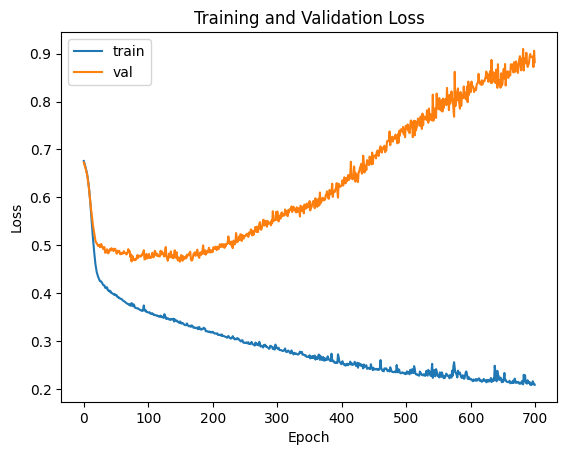

Test loss:0.7620	Test accuracy:0.76


In [5]:
import matplotlib.pyplot as pyplot

# Instantiate the model (if not already done or to re-initialize for a fresh training)
model = SimpleNN(input_features) # Uncomment if you want to re-initialize the model

# Definimos la función de pérdida y el optimizador
loss_fn = nn.BCEWithLogitsLoss() # Use BCEWithLogitsLoss for numerical stability with sigmoid output
optimizer = optim.Adam(model.parameters(), lr=0.001) # Example learning rate

num_epochs = 700

train_losses, val_losses = train_model(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
    val_loader=val_loader
)

pyplot.plot(train_losses, label="train")
pyplot.plot(val_losses, label="val")
pyplot.xlabel("Epoch")
pyplot.ylabel("Loss")
pyplot.title("Training and Validation Loss")
pyplot.legend()
pyplot.show()

test_loss, test_accuracy = measure_model(model, loss_fn, test_loader)
print(f'Test loss:{test_loss:.4f}\tTest accuracy:{test_accuracy:.2f}')

En la curva de entrenamiento deberías ser capaz de identificar que hay sobreentrenamiento porque la curva de validación llega a un punto que deja de mejorar y comienza a empeorar.

*NOTA: Puedes exagerar el efecto de sobreajuste tomando menos datos de entrenamiento, lo cual facilita su memorización.*

# Regularización
Una vez diagnosticado el sobreajuste, es hora de probar diferentes técnicas que intenten reducir la varianza, sin incrementar demasiado el sesgo y, con ello, el modelo generaliza mejor. Las técnicas de regularización que vamos a ver en este laboratorio son:
1. *Early stopping*. Detiene el entrenamiento de la red cuando aumenta el error.
1. Penalización basada	en	la	norma	de	los	parámetros (tanto norma L1 como L2).
1. *Dropout*. Ampliamente utilizada en aprendizaje profundo, "desactiva" algunas neuronas para evitar el sobreajuste.

## Parte 1. Early Stopping
Hacer parada temprana (*early stopping*) consiste en monitorizar el rendimiento en un pequeño subconjunto del conjunto de entrenamiento y parar el aprendizaje cuando este rendimiento decaiga.

Para llevarlo a cabo, añade a la función de `train_model` un parámetro opcional llamado `patience` que indique durantos cuántos pasos puede empeorar el la pérdida en validación sin que se pare el entrenamiento. Cuando esté presente el valor de `patience` el entrenamiento se tiene que parar atendiendo a él.

Una vez tengas la función, vuelve a declarar el modelo y optimizador, entrena y revisa las curvas y el rendimiento en test.

In [ ]:
# TODO - Instancia un modelo y un optimizador, haz el entrenamiento con early stopping y muestra las curvas y medidas

# Parte 2. Penalización basada en norma de parámetros
Otra alternativa para regularizar consiste en añadir a la función de pérdida una componente que penalice los valores altos en los parámetros. En `torch` le podemos indicar al optimizador que incluya una penalización L2 en los pesos indicando el parámetro `weight_decay` al instanciarlo. Prueba distintos valores (suele ser buena política probar cambios en factores de 10 alrededor del 0.001) y comprueba su efecto en el rendimiento. No utilices *early stopping* en el entrenamiento.

**¿Qué diferencia observas en la curva de entrenamiento con respecto a utilizar *early stopping*?**

In [ ]:
# TODO - Instancia un modelo y un optimizador con weight decay, haz el entrenamiento y muestra las curvas y medidas

# Parte 3. Dropout
Por último, la tercera alternativa que exploraremos para regularizar es añadir capas `nn.Dropout` a nuestra arquitectura. Estas capas apagan durante el entrenamiento una fracción (que debemos indicar como parámetro al instanciar la capa) de las neuronas que reciben a la entrada, impidiendo al modelo apoyarse siempre en las mismas entradas para hacer sus predicciones, forzándolo así a aprender representaciones más generales y, por tanto, mejorando su generalización.

Crea una nueva arquitectura de red con estas capas y entrénala (sin usar ningún otro mecanismo de regularización). Prueba a situar las capas `nn.Dropout` en distintos sitios y a aplicar distintos valores del parámetro `p` que indica la probabilidad de que se apague cada neurona.

In [ ]:

# TODO - Declara la nueva clase, haz que tu modelo sea una instancia de ella, instancia el optimizador, haz el entrenamiento y muestra las curvas y medidas.